# Migration, differentiation, and pooled genotypes

Two populations have different allele frequencies. What changes when people move between them, and what goes wrong if we pool their genotypes without remembering where they came from?

We will follow one allele at one locus. Each population is assumed to be large, with equal size, and to mate randomly within itself. We leave out drift and selection so that migration is the only force moving the allele frequencies.

## The model

Let $p_{1,t}$ and $p_{2,t}$ be the allele frequencies. Each generation, a fraction $m$ of each population comes from the other:

$$
p_{1,t+1}=(1-m)p_{1,t}+mp_{2,t},\qquad
p_{2,t+1}=(1-m)p_{2,t}+mp_{1,t}.
$$

The mean $\bar p=(p_1+p_2)/2$ stays fixed. The gap $p_1-p_2$ becomes $(1-2m)(p_1-p_2)$ after one generation. With $0<m<1/2$, migration narrows the gap; it does not move both populations in the same direction.

To measure differentiation, compare the heterozygosity expected from the pooled frequency, $H_T=2\bar p(1-\bar p)$, with the mean heterozygosity within populations, $H_S=\{2p_1(1-p_1)+2p_2(1-p_2)\}/2$. Here $F_{ST}=(H_T-H_S)/H_T$.

## One example

Start at $p_1=0.75$ and $p_2=0.25$, with $m=0.05$. We expect the frequencies to approach 0.5 from opposite directions and $F_{ST}$ to fall. If $m=0$, neither frequency changes. These are useful checks before we run the code.

In [1]:
follow_migration <- function(p1, p2, m, generations) {
  frequency <- matrix(NA_real_, nrow = generations + 1, ncol = 2)
  frequency[1, ] <- c(p1, p2)
  for (t in seq_len(generations)) {
    frequency[t + 1, ] <- c(
      (1 - m) * frequency[t, 1] + m * frequency[t, 2],
      (1 - m) * frequency[t, 2] + m * frequency[t, 1]
    )
  }
  colnames(frequency) <- c("population 1", "population 2")
  frequency
}

fst <- function(p1, p2) {
  pooled <- (p1 + p2) / 2
  h_total <- 2 * pooled * (1 - pooled)
  h_within <- p1 * (1 - p1) + p2 * (1 - p2)
  (h_total - h_within) / h_total
}

frequency <- follow_migration(0.75, 0.25, m = 0.05, generations = 30)
time <- 0:30
stopifnot(all(frequency >= 0 & frequency <= 1))
stopifnot(isTRUE(all.equal(rowMeans(frequency), rep(0.5, length(time)))))
stopifnot(isTRUE(all.equal(follow_migration(0.75, 0.25, 0, 1)[2, ],
                           c("population 1" = 0.75, "population 2" = 0.25))))

The first panel shows the allele frequencies. The second shows how their difference changes $F_{ST}$. The dashed line is the prediction from the shrinking frequency gap.

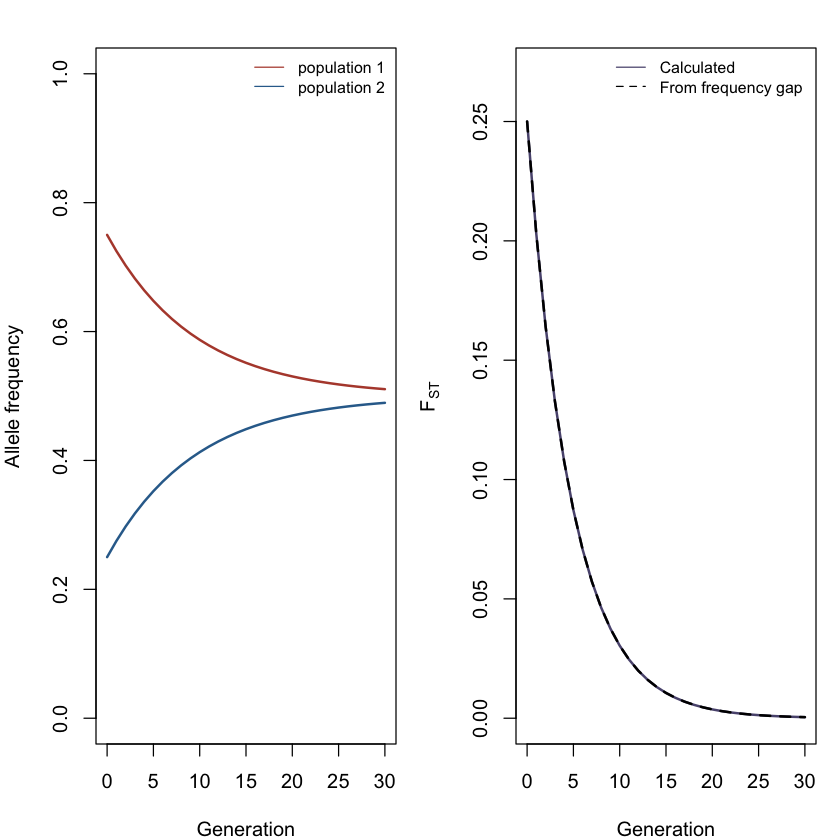

In [2]:
observed_fst <- fst(frequency[, 1], frequency[, 2])
predicted_fst <- fst(0.75, 0.25) * (1 - 2 * 0.05)^(2 * time)

old_par <- par(mfrow = c(1, 2), mar = c(4, 4, 2, 1), bg = "white")
matplot(time, frequency, type = "l", lwd = 2, lty = 1,
        col = c("#B44A3A", "#306C9A"), xlab = "Generation",
        ylab = "Allele frequency", ylim = c(0, 1))
legend("topright", colnames(frequency), col = c("#B44A3A", "#306C9A"),
       lty = 1, bty = "n", cex = 0.8)
plot(time, observed_fst, type = "l", lwd = 2, col = "#5A547D",
     xlab = "Generation", ylab = expression(F[ST]), ylim = c(0, 0.27))
lines(time, predicted_fst, lty = 2, lwd = 2)
legend("topright", c("Calculated", "From frequency gap"),
       col = c("#5A547D", "black"), lty = c(1, 2), bty = "n", cex = 0.8)
par(old_par)
stopifnot(isTRUE(all.equal(observed_fst, predicted_fst)))

## Why pooling can mislead us

Before migration, the pooled allele frequency is 0.5, so Hardy–Weinberg would predict a heterozygote frequency of $H_T=0.5$. But each population has heterozygote frequency $2(0.75)(0.25)=0.375$. The pooled sample therefore has a heterozygote deficit even though each population is in Hardy–Weinberg equilibrium. This is the **Wahlund effect**.

No individual needs to be inbred for this deficit to appear. The difference comes from mixing populations with different allele frequencies. As migration narrows that difference, the deficit and $F_{ST}$ both fall.

In [3]:
data.frame(
  quantity = c("Pooled HWE heterozygosity", "Observed pooled heterozygosity",
               "Heterozygote deficit", "F_ST"),
  initial = round(c(0.5, 0.375, 0.125, observed_fst[1]), 3),
  after_30_generations = round(c(
    0.5,
    frequency[31, 1] * (1 - frequency[31, 1]) +
      frequency[31, 2] * (1 - frequency[31, 2]),
    0.5 - (frequency[31, 1] * (1 - frequency[31, 1]) +
             frequency[31, 2] * (1 - frequency[31, 2])),
    observed_fst[31]
  ), 3)
)

quantity,initial,after_30_generations
<chr>,<dbl>,<dbl>
Pooled HWE heterozygosity,0.500,0.5
Observed pooled heterozygosity,0.375,0.5
Heterozygote deficit,0.125,0.0
F_ST,0.250,0.0


## What to remember

Migration mixes allele frequencies. A pooled genotype sample can show a heterozygote deficit because it contains distinct populations, not because its members are necessarily inbred. The same frequency differences appear in $F_{ST}$.

**Sources.** Pritchard, *An Owner's Guide to the Human Genome*, Section 2.4; Gorroochurn, *Population Genetics Notes*, Sections 9.1–9.7; Láruson and Reed, *Population Genetics with R*, Chapter 8. The equal-sized, symmetric two-population calculation is an original small illustration of the standard migration recursion; it uses no book data and no random seed.